# Morphosyntactic Analysis of the Rap Corpus with Stanza

This notebook uses the French Stanza `combined` pipeline on GPU to annotate the **complete eligible corpus**.

## Full-Run Scope

- word counts are computed from the lyrics actually loaded;
- only songs containing **10 to 4,000 words inclusive** are eligible;
- all eligible songs are retained, with no sampling;
- each non-empty lyric line is treated as a separate Stanza sentence;
- earlier `full`, `1pct`, and `1pct_10to4000w` fragments remain isolated from the `full_10to4000w` scope.

The notebook exports CoNLL-U-style annotations, syntactic dependencies, GPU performance metrics, POS distributions, lexical frequencies, and figures. Each executed cell reports the counts actually obtained.

## 1. Import Required Libraries and Setup

In [10]:
import codecs
import csv
import json
import shutil
import time
import warnings
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import stanza
import torch
from tqdm.auto import tqdm
from wordcloud import WordCloud

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# Palette defined in the Rap project visual skill.
plt.style.use('dark_background')
HIP_HOP_PALETTE = {
    'black': '#000000',
    'dark_gray': '#1a1a1a',
    'gold': '#FFD700',
    'orange': '#FF8C00',
    'red': '#DC143C',
}

POS_COLORS = {
    'NOUN': '#FF8C00',
    'PROPN': '#FF4500',
    'VERB': '#FFD700',
    'ADJ': '#DC143C',
    'ADV': '#FFA500',
    'OTHER': '#808080',
}

print(f"Stanza: {stanza.__version__}")
print(f"PyTorch: {torch.__version__}")
print("Progress bars: tqdm available")

Stanza: 1.14.0
PyTorch: 2.4.0+cu121
Progress bars: tqdm available


## 2. Setup Output Directories

In [11]:
# Create output directories
images_dir = Path('images')
export_dir = Path('export')

images_dir.mkdir(exist_ok=True)
export_dir.mkdir(exist_ok=True)

print(f"✓ 'images' folder: {images_dir.resolve()}")
print(f"✓ 'export' folder: {export_dir.resolve()}")

✓ 'images' folder: /home/cbenavent/test/Rap/images
✓ 'export' folder: /home/cbenavent/test/Rap/export


## 3. Load the Corpus

This cell only opens `corpus.csv` and checks that the `lyrics` column is available. It is kept separate from model loading so that data errors can be distinguished clearly from GPU-related errors.

In [12]:
# Read the source corpus.
corpus_path = Path('corpus.csv')

try:
    df = pd.read_csv(corpus_path, encoding='utf-8', on_bad_lines='skip')
except UnicodeDecodeError:
    df = pd.read_csv(corpus_path, encoding='latin-1', on_bad_lines='skip')

text_col = 'lyrics'
if text_col not in df.columns:
    raise KeyError(f"Missing required column: {text_col}")

print(f"Corpus loaded: {len(df):,} documents")
print(f"Text column: {text_col}")

Corpus loaded: 85,023 documents
Text column: lyrics


## 4. Technical Choice: French Stanza on GPU

### Why Stanza?

The French `combined` package brings together several Universal Dependencies treebanks and provides tokenization, universal POS tags, morphology, lemmatization, and dependency parsing in one pipeline. It is better suited to a CoNLL-U-style export than the initially tested small spaCy model.

### Why a Contextual Model Instead of a Large Lexicon Alone?

Rap lyrics contain contractions, slang, anglicisms, and novel spellings. A large lexicon improves coverage of known forms, whereas a contextual neural model can also analyze unseen forms from their context. A pilot remains necessary because the training domain is not specifically rap.

### Why a Single GPU?

Stanza runs its neural networks through PyTorch on CUDA, but one pipeline is not distributed automatically across several GPUs. For this 1% pilot, a single H100 avoids the complexity and overhead of multiprocessing. Multi-GPU processing should only be considered after measuring throughput.

### Model-Loading Precaution

With PyTorch 2.4, the official Stanza model requires `_codecs.encode` to be added explicitly to the safe globals used when loading weights. This targeted allowance is applied only to the official downloaded Stanza model.

In [13]:
# This notebook evaluates the pipeline explicitly on CUDA device 0.
if not torch.cuda.is_available():
    raise RuntimeError("CUDA is unavailable; the GPU pilot cannot run.")

gpu_index = 0
torch.cuda.set_device(gpu_index)
gpu_name = torch.cuda.get_device_name(gpu_index)

# PyTorch 2.4 requires this targeted allowlist for the official Stanza weights.
torch.serialization.add_safe_globals([codecs.encode])

# Each input unit is one lyric line. Dependencies therefore remain inside a line.
nlp = stanza.Pipeline(
    lang='fr',
    package='combined',
    processors='tokenize,mwt,pos,lemma,depparse',
    tokenize_no_ssplit=True,
    use_gpu=True,
    device=f'cuda:{gpu_index}',
    verbose=False,
)

# Inspect an actual model parameter: CUDA visibility alone is not proof of GPU use.
pos_model = nlp.processors['pos']._trainer.model
model_device = next(pos_model.parameters()).device
if model_device.type != 'cuda' or model_device.index != gpu_index:
    raise RuntimeError(f"Stanza model is on {model_device}, expected cuda:{gpu_index}")

torch.cuda.reset_peak_memory_stats(gpu_index)

print(f"CUDA available: {torch.cuda.is_available()}")
print(f"Selected device: cuda:{gpu_index}")
print(f"GPU: {gpu_name}")
print(f"Stanza POS model device: {model_device}")
print("Segmentation rule: one non-empty lyric line = one syntactic sentence")

CUDA available: True
Selected device: cuda:0
GPU: NVIDIA H100 NVL
Stanza POS model device: cuda:0
Segmentation rule: one non-empty lyric line = one syntactic sentence


## 5. Complete GPU Run

Lyrics containing **10 to 4,000 words inclusive** are retained and processed in full. No sampling or text truncation is applied.

Each newline `\n` marks a lyric-line boundary. Non-empty lines are sent separately to Stanza with `tokenize_no_ssplit=True`, so syntactic dependencies never cross from one lyric line to another.

Annotations are written in resumable batches under the `full_10to4000w` label. Each completed batch is persisted atomically, and the progress bar reports ETA and observed throughput.

In [29]:
# Select either the complete eligible corpus or a reproducible pilot sample.
run_full_corpus = True
pilot_fraction = 0.01
sample_fraction = 1.0 if run_full_corpus else pilot_fraction
sample_label = 'full_10to4000w' if run_full_corpus else '1pct_10to4000w'
random_state = 42
min_words_per_document = 10
max_words_per_document = 4000

text_values = df[text_col].fillna('').astype(str).str.strip()
word_counts = text_values.str.split().str.len()
eligible_mask = (
    text_values.ne('')
    & word_counts.between(
        min_words_per_document,
        max_words_per_document,
        inclusive='both',
    )
)
eligible_texts = df.loc[eligible_mask].copy()
eligible_texts['word_count'] = word_counts.loc[eligible_mask]

if run_full_corpus:
    df_sample = eligible_texts.copy()
else:
    df_sample = eligible_texts.sample(
        frac=sample_fraction,
        random_state=random_state,
    ).copy()

assert df_sample['word_count'].between(
    min_words_per_document,
    max_words_per_document,
    inclusive='both',
).all()
if run_full_corpus:
    assert len(df_sample) == len(eligible_texts)

# Preserve lyric line breaks and map every non-empty line back to its song.
line_records = []
for document_id, (source_row_index, raw_text) in enumerate(
    tqdm(
        df_sample[text_col].astype(str).items(),
        total=len(df_sample),
        desc='Preparing lyrics',
        unit='songs',
        dynamic_ncols=True,
    ),
    start=1,
):
    normalized_text = raw_text.replace('\r\n', '\n').replace('\r', '\n')

    for lyric_line_id, lyric_line in enumerate(normalized_text.split('\n'), start=1):
        lyric_line = lyric_line.strip()
        if lyric_line:
            line_records.append({
                'document_id': document_id,
                'source_row_index': source_row_index,
                'lyric_line_id': lyric_line_id,
                'text': lyric_line,
            })

line_units_df = pd.DataFrame(line_records)
texts = line_units_df['text'].tolist()

print(f"Run scope: {sample_label}")
print(
    f"Eligible songs ({min_words_per_document}-{max_words_per_document} words): "
    f"{len(eligible_texts):,} / {len(df):,}"
)
print(f"Songs selected: {len(df_sample):,}")
print(f"Observed word range: {df_sample['word_count'].min():,}-{df_sample['word_count'].max():,}")
print(f"Non-empty lyric lines: {len(line_units_df):,}")
print(f"Random seed: {random_state}")

Preparing lyrics:   0%|          | 0/84155 [00:00<?, ?songs/s]

Run scope: full_10to4000w
Eligible songs (10-4000 words): 84,155 / 85,023
Songs selected: 84,155
Observed word range: 10-3,964
Non-empty lyric lines: 4,631,248
Random seed: 42


### 5.1 Lyric-Paragraph Length Analysis

One or more empty lines separate lyric paragraphs or blocks. This cell measures their length before choosing a context unit. A complete paragraph may provide richer lexical context, but it should not be forced into a single sentence when its length would produce an artificial dependency tree.

In [30]:
# Measure lyric paragraphs separated by one or more empty lines.
paragraph_records = []

for document_id, (source_row_index, raw_text) in enumerate(
    df_sample[text_col].astype(str).items(),
    start=1,
):
    normalized_text = raw_text.replace('\r\n', '\n').replace('\r', '\n')
    paragraph_lines = []
    paragraph_id = 0

    for raw_line in normalized_text.split('\n') + ['']:
        clean_line = raw_line.strip()
        if clean_line:
            paragraph_lines.append(clean_line)
            continue
        if not paragraph_lines:
            continue

        paragraph_id += 1
        paragraph_text = '\n'.join(paragraph_lines)
        paragraph_records.append({
            'document_id': document_id,
            'source_row_index': source_row_index,
            'paragraph_id': paragraph_id,
            'line_count': len(paragraph_lines),
            'word_count_approx': len(paragraph_text.split()),
            'character_count': len(paragraph_text),
        })
        paragraph_lines = []

paragraph_stats = pd.DataFrame(paragraph_records)
paragraph_quantiles = paragraph_stats[
    ['line_count', 'word_count_approx', 'character_count']
].quantile([0.50, 0.75, 0.90, 0.95, 0.99]).round(1)
paragraph_path = export_dir / f'R01_paragraph_statistics_{sample_label}.csv'
paragraph_stats.to_csv(paragraph_path, index=False)

print(f"Paragraphs detected: {len(paragraph_stats):,}")
print(f"Paragraphs per song: {len(paragraph_stats) / len(df_sample):.1f}")
print(f"Paragraphs longer than 4 lines: {(paragraph_stats['line_count'] > 4).mean():.1%}")
print(f"Paragraphs longer than 8 lines: {(paragraph_stats['line_count'] > 8).mean():.1%}")
print(f"Paragraphs longer than 100 words: {(paragraph_stats['word_count_approx'] > 100).mean():.1%}")
print(f"Statistics saved: {paragraph_path}")
print("\nQuantiles:")
paragraph_quantiles

Paragraphs detected: 498,065
Paragraphs per song: 5.9
Paragraphs longer than 4 lines: 63.9%
Paragraphs longer than 8 lines: 36.6%
Paragraphs longer than 100 words: 26.3%
Statistics saved: export/paragraph_statistics_full_10to4000w.csv

Quantiles:


,line_count,word_count_approx,character_count
0.50,8.0,54.0,294.0
0.75,12.0,105.0,579.0
0.90,19.0,169.0,937.0
0.95,25.0,215.0,1197.0
0.99,43.0,380.0,2115.4


### 5.2 GPU Annotation Benchmark by Lyric Line

This cell measures the complete Stanza linguistic pipeline, including syntactic dependencies. Each input is one non-empty lyric line and must produce exactly one Stanza sentence. CUDA is synchronized before and after annotation so that elapsed time includes the work actually performed on the GPU.

Reported metrics include elapsed time, songs/s, lines/s, words/s, peak GPU memory, and a linear estimate for the complete corpus.

In [31]:
# Annotate the full corpus in resumable chunks and stream CoNLL-U rows to disk.
annotation_batch_size = 5000
conllu_columns = [
    'document_id', 'source_row_index', 'sentence_id',
    'id', 'form', 'lemma', 'upos', 'xpos', 'feats',
    'head', 'deprel', 'deps', 'misc',
]
conllu_path = export_dir / f'R01_pos_{sample_label}_conllu.csv'
parts_dir = export_dir / f'.pos_{sample_label}_parts'
parts_dir.mkdir(exist_ok=True)
total_batches = (len(texts) + annotation_batch_size - 1) // annotation_batch_size

# Recover completed chunks from a previous interrupted execution.
completed_lines = 0
processed_words_live = 0
benchmark_seconds = 0.0
for batch_index in range(total_batches):
    metadata_path = parts_dir / f'part_{batch_index:05d}.json'
    part_path = parts_dir / f'part_{batch_index:05d}.csv'
    if metadata_path.exists() and part_path.exists():
        with metadata_path.open('r', encoding='utf-8') as metadata_file:
            batch_metadata = json.load(metadata_file)
        completed_lines += batch_metadata['lines']
        processed_words_live += batch_metadata['words']
        benchmark_seconds += batch_metadata['seconds']
    elif metadata_path.exists() or part_path.exists():
        metadata_path.unlink(missing_ok=True)
        part_path.unlink(missing_ok=True)

torch.cuda.empty_cache()
torch.cuda.reset_peak_memory_stats(gpu_index)
torch.cuda.synchronize(gpu_index)

with tqdm(
    total=len(texts),
    initial=completed_lines,
    desc='Annotation Stanza complète',
    unit='vers',
    dynamic_ncols=True,
) as progress_bar:
    for batch_index, batch_start in enumerate(
        range(0, len(texts), annotation_batch_size)
    ):
        batch_end = min(batch_start + annotation_batch_size, len(texts))
        part_path = parts_dir / f'part_{batch_index:05d}.csv'
        metadata_path = parts_dir / f'part_{batch_index:05d}.json'
        if part_path.exists() and metadata_path.exists():
            continue

        batch_texts = texts[batch_start:batch_end]
        batch_line_metadata = line_units_df.iloc[batch_start:batch_end]
        torch.cuda.synchronize(gpu_index)
        batch_started = time.perf_counter()
        batch_documents = nlp.bulk_process(batch_texts)
        torch.cuda.synchronize(gpu_index)
        batch_seconds = time.perf_counter() - batch_started

        assert len(batch_documents) == len(batch_texts)
        assert all(len(document.sentences) == 1 for document in batch_documents)

        part_temp_path = part_path.with_suffix('.csv.tmp')
        batch_words = 0
        with part_temp_path.open('w', encoding='utf-8', newline='') as part_file:
            writer = csv.DictWriter(part_file, fieldnames=conllu_columns)
            writer.writeheader()
            for line_metadata, line_document in zip(
                batch_line_metadata.itertuples(index=False),
                batch_documents,
            ):
                for word in line_document.sentences[0].words:
                    writer.writerow({
                        'document_id': line_metadata.document_id,
                        'source_row_index': line_metadata.source_row_index,
                        'sentence_id': line_metadata.lyric_line_id,
                        'id': word.id,
                        'form': word.text,
                        'lemma': word.lemma or '_',
                        'upos': word.upos or '_',
                        'xpos': word.xpos or '_',
                        'feats': word.feats or '_',
                        'head': word.head,
                        'deprel': word.deprel or '_',
                        'deps': word.deps or '_',
                        'misc': word.misc or '_',
                    })
                    batch_words += 1
        part_temp_path.replace(part_path)

        batch_metadata = {
            'batch_index': batch_index,
            'start': batch_start,
            'end': batch_end,
            'lines': len(batch_texts),
            'words': batch_words,
            'seconds': batch_seconds,
        }
        metadata_temp_path = metadata_path.with_suffix('.json.tmp')
        with metadata_temp_path.open('w', encoding='utf-8') as metadata_file:
            json.dump(batch_metadata, metadata_file)
        metadata_temp_path.replace(metadata_path)

        completed_lines += len(batch_texts)
        processed_words_live += batch_words
        benchmark_seconds += batch_seconds
        progress_bar.update(len(batch_texts))
        progress_bar.set_postfix(
            mots=f'{processed_words_live:,}',
            mots_s=f'{processed_words_live / benchmark_seconds:,.0f}',
        )

assert completed_lines == len(texts), 'Incomplete lyric-line annotation'

# Merge validated chunks into one final CSV without loading them into memory.
final_temp_path = conllu_path.with_suffix('.csv.tmp')
with final_temp_path.open('w', encoding='utf-8', newline='') as final_file:
    final_file.write(','.join(conllu_columns) + '\n')
    for batch_index in tqdm(
        range(total_batches),
        desc='Fusion des fragments',
        unit='lots',
        dynamic_ncols=True,
    ):
        part_path = parts_dir / f'part_{batch_index:05d}.csv'
        with part_path.open('r', encoding='utf-8', newline='') as part_file:
            next(part_file)
            shutil.copyfileobj(part_file, final_file)
final_temp_path.replace(conllu_path)

processed_documents = len(df_sample)
processed_lines = completed_lines
processed_sentences = completed_lines
processed_words = processed_words_live
peak_gpu_memory_gib = torch.cuda.max_memory_allocated(gpu_index) / (1024 ** 3)
documents_per_second = processed_documents / benchmark_seconds
lines_per_second = processed_lines / benchmark_seconds
sentences_per_second = lines_per_second
words_per_second = processed_words / benchmark_seconds
estimated_full_minutes = benchmark_seconds / 60

performance_metrics = pd.DataFrame([{
    'gpu_index': gpu_index,
    'gpu_name': gpu_name,
    'sample_fraction': sample_fraction,
    'sample_documents': processed_documents,
    'lyric_lines': processed_lines,
    'sentences': processed_sentences,
    'words': processed_words,
    'elapsed_seconds': benchmark_seconds,
    'documents_per_second': documents_per_second,
    'lines_per_second': lines_per_second,
    'sentences_per_second': sentences_per_second,
    'words_per_second': words_per_second,
    'peak_gpu_memory_gib': peak_gpu_memory_gib,
    'estimated_full_minutes': estimated_full_minutes,
}])

print(f"GPU: cuda:{gpu_index} - {gpu_name}")
print(f"Annotation time: {benchmark_seconds:.2f} s")
print(f"Songs: {processed_documents:,} ({documents_per_second:,.2f} songs/s)")
print(f"Lyric lines: {processed_lines:,} ({lines_per_second:,.2f} lines/s)")
print(f"Words: {processed_words:,} ({words_per_second:,.2f} words/s)")
print(f"Peak allocated GPU memory: {peak_gpu_memory_gib:.2f} GiB")
print(f"Final export: {conllu_path}")

Annotation Stanza complète:   0%|          | 0/4631248 [00:00<?, ?vers/s]

Fusion des fragments:   0%|          | 0/927 [00:00<?, ?lots/s]

GPU: cuda:0 - NVIDIA H100 NVL
Annotation time: 18819.10 s
Songs: 84,155 (4.47 songs/s)
Lyric lines: 4,631,248 (246.09 lines/s)
Words: 48,318,712 (2,567.54 words/s)
Peak allocated GPU memory: 16.90 GiB
Final export: export/pos_full_10to4000w_conllu.csv


In [32]:
# Persist benchmark results for later model comparisons.
performance_path = export_dir / f'R01_stanza_gpu0_performance_{sample_label}.csv'
performance_metrics.to_csv(performance_path, index=False)

print(f"Performance metrics saved: {performance_path}")
performance_metrics

Performance metrics saved: export/stanza_gpu0_performance_full_10to4000w.csv


,gpu_index,gpu_name,sample_fraction,sample_documents,lyric_lines,sentences,words,elapsed_seconds,documents_per_second,lines_per_second,sentences_per_second,words_per_second,peak_gpu_memory_gib,estimated_full_minutes
0,0,NVIDIA H100 NVL,1.0,84155,4631248,4631248,48318712,18819.097812,4.471787,246.092987,246.092987,2567.536047,16.897736,313.65163


In [33]:
# Aggregate POS statistics from the annotation CSV in bounded-memory chunks.
main_pos = ['NOUN', 'PROPN', 'VERB', 'ADJ', 'ADV']
pos_counts = Counter()
pos_words = {pos: Counter() for pos in main_pos}
document_totals = Counter()
document_pos_counts = {pos: Counter() for pos in main_pos}
aggregated_words = 0

for annotation_chunk in tqdm(
    pd.read_csv(conllu_path, chunksize=500_000),
    total=max((processed_words + 499_999) // 500_000, 1),
    desc='Agrégation des annotations',
    unit='blocs',
    dynamic_ncols=True,
):
    aggregated_words += len(annotation_chunk)
    pos_counts.update(annotation_chunk['upos'].value_counts().to_dict())
    document_totals.update(
        annotation_chunk.groupby('document_id').size().to_dict()
    )

    for pos_tag in main_pos:
        pos_chunk = annotation_chunk[annotation_chunk['upos'].eq(pos_tag)]
        document_pos_counts[pos_tag].update(
            pos_chunk.groupby('document_id').size().to_dict()
        )
        lemmas = pos_chunk['lemma'].astype(str).str.lower().str.strip()
        valid_lemmas = lemmas[
            lemmas.str.isalpha()
            & lemmas.str.len().gt(1)
        ]
        pos_words[pos_tag].update(valid_lemmas.value_counts().to_dict())

    if annotation_chunk['head'].isna().any():
        raise ValueError('Missing syntactic heads in the annotation export')
    if annotation_chunk['deprel'].isna().any() or annotation_chunk['deprel'].eq('_').any():
        raise ValueError('Missing dependency relations in the annotation export')

assert aggregated_words == processed_words
assert len(document_totals) == processed_documents

doc_pos_ratios = [
    {
        pos_tag: document_pos_counts[pos_tag][document_id] / document_totals[document_id]
        for pos_tag in main_pos
    }
    for document_id in sorted(document_totals)
]
annotations_df = pd.read_csv(conllu_path, nrows=10)

print(f"CoNLL-U-style export: {conllu_path}")
print(f"Rows validated: {aggregated_words:,}")
print(f"Songs validated: {len(document_totals):,}")
print(f"Annotated tokens: {pos_counts.total():,}")
annotations_df

Agrégation des annotations:   0%|          | 0/97 [00:00<?, ?blocs/s]

CoNLL-U-style export: export/pos_full_10to4000w_conllu.csv
Rows validated: 48,318,712
Songs validated: 84,155
Annotated tokens: 48,318,712


,document_id,source_row_index,sentence_id,id,form,lemma,upos,xpos,feats,head,deprel,deps,misc
0,1,0,1,1,[,[,PUNCT,_,_,2,punct,_,_
1,1,0,1,2,Paroles,parole,NOUN,_,Number=Plur,0,root,_,_
2,1,0,1,3,de,de,ADP,_,_,5,case,_,_
3,1,0,1,4,"""","""",PUNCT,_,_,5,punct,_,_
4,1,0,1,5,94310,94310,NUM,_,NumType=Card,2,nmod,_,_
5,1,0,1,6,"""","""",PUNCT,_,_,5,punct,_,_
6,1,0,1,7,ft.,ft.,X,_,_,8,punct,_,_
7,1,0,1,8,Madj,Madj,PROPN,_,_,2,nmod,_,_
8,1,0,1,9,",",",",PUNCT,_,_,10,punct,_,_
9,1,0,1,10,Larso,Larso,PROPN,_,_,2,nmod,_,_


## 6. POS Distribution Analysis

In [34]:
print("\n" + "=" * 60)
print(f"MAIN POS STATISTICS - {sample_fraction:.1%} STANZA PILOT")
print("=" * 60)

total_pos_tokens = sum(pos_counts.values())
all_pos_summary = pd.DataFrame([
    {
        'pos_tag': pos,
        'count': count,
        'percentage': count / total_pos_tokens * 100,
    }
    for pos, count in pos_counts.most_common()
])

main_pos_summary = (
    all_pos_summary[all_pos_summary['pos_tag'].isin(main_pos)]
    .set_index('pos_tag')
    .reindex(main_pos)
    .reset_index()
)
main_pos_summary['mean_document_ratio'] = [
    np.mean([ratios.get(pos, 0) for ratios in doc_pos_ratios]) * 100
    for pos in main_pos
]
main_pos_summary['unique_modalities'] = [len(pos_words[pos]) for pos in main_pos]

print(main_pos_summary.to_string(index=False))

all_pos_summary.to_csv(export_dir / f'R01_pos_distribution_all_{sample_label}.csv', index=False)
main_pos_summary.to_csv(export_dir / f'R01_main_pos_statistics_{sample_label}.csv', index=False)
print(f"\nComplete distribution: export/pos_distribution_all_{sample_label}.csv")
print(f"Main POS statistics: export/main_pos_statistics_{sample_label}.csv")


MAIN POS STATISTICS - 100.0% STANZA PILOT
pos_tag   count  percentage  mean_document_ratio  unique_modalities
   NOUN 7793422   16.129201            16.066240              77358
  PROPN 1407971    2.913925             2.970443              81158
   VERB 6627455   13.716125            13.747413              19737
    ADJ 1536522    3.179973             3.193084              18963
    ADV 2575149    5.329507             5.378416               2222

Complete distribution: export/pos_distribution_all_full_10to4000w.csv
Main POS statistics: export/main_pos_statistics_full_10to4000w.csv


## 7. Strongly Weighted Word Clouds by Linguistic Category

The first five word clouds show the **100 most frequent lemmas** for `NOUN`, `PROPN`, `VERB`, `ADJ`, and `ADV`. No stopword list is applied: filtering retains alphabetic lemmas of at least two characters within each POS category.

A sixth cloud fills the final panel with punctuation, symbols, and vocal expressions. It combines the surface forms tagged `PUNCT` or `SYM` with alphabetic `INTJ` lemmas used as a reproducible proxy for interjections and likely onomatopoeia.

Font size is determined by **rank**, with a strongly accentuated decrease bounded between 10% and 100% of the maximum size. Leading modalities dominate clearly while the long tail remains visible at a smaller scale.

Figure saved: images/02_wordcloud_rank_noun_full_10to4000w.png
Figure saved: images/02_wordcloud_rank_propn_full_10to4000w.png
Figure saved: images/02_wordcloud_rank_verb_full_10to4000w.png
Figure saved: images/02_wordcloud_rank_adj_full_10to4000w.png
Figure saved: images/02_wordcloud_rank_adv_full_10to4000w.png
Figure saved: images/02_wordcloud_rank_expressive_full_10to4000w.png
Overview saved: images/02_pos_word_clouds_rank_full_10to4000w.png


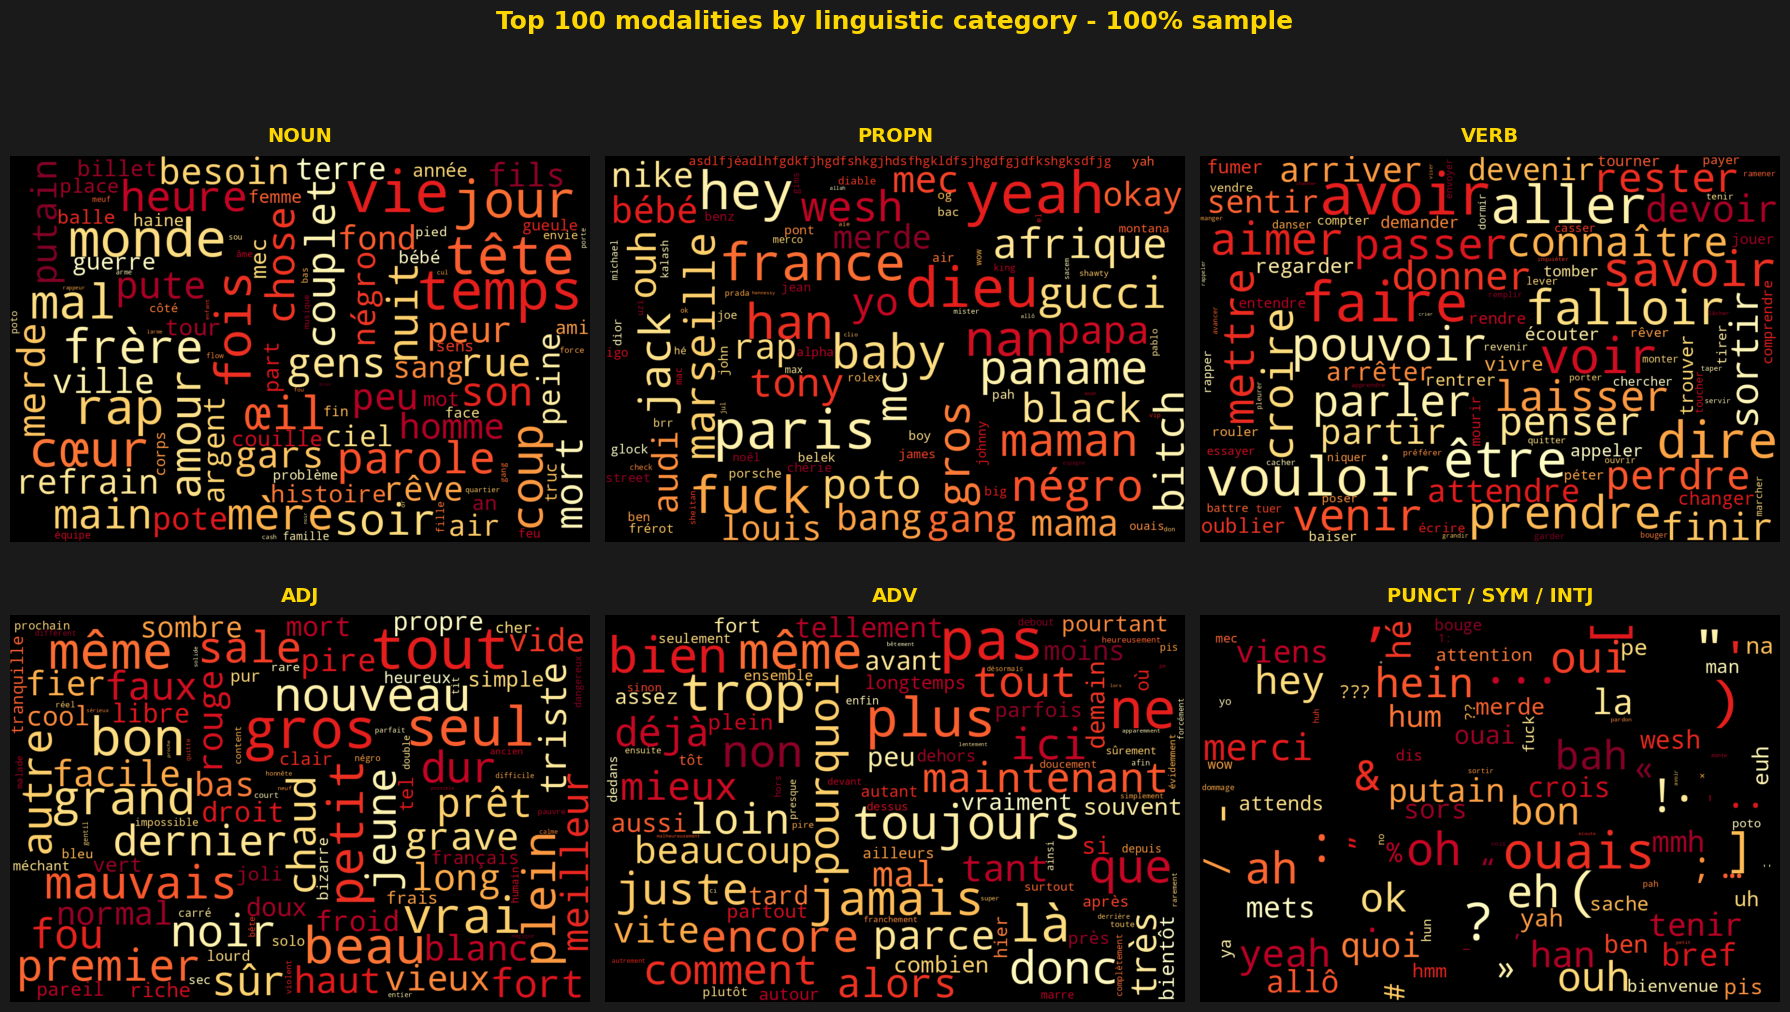

In [35]:
# Generate six strongly rank-weighted word clouds, including vocal expressions.
wordcloud_categories = ['NOUN', 'PROPN', 'VERB', 'ADJ', 'ADV', 'EXPRESSIVE']
category_titles = {
    'NOUN': 'NOUN',
    'PROPN': 'PROPN',
    'VERB': 'VERB',
    'ADJ': 'ADJ',
    'ADV': 'ADV',
    'EXPRESSIVE': 'PUNCT / SYM / INTJ',
}
category_slugs = {
    'NOUN': 'noun',
    'PROPN': 'propn',
    'VERB': 'verb',
    'ADJ': 'adj',
    'ADV': 'adv',
    'EXPRESSIVE': 'expressive',
}
ranked_modalities = {
    pos_tag: pos_words[pos_tag].most_common(100)
    for pos_tag in wordcloud_categories[:-1]
}

# PUNCT and SYM preserve their surface form; INTJ provides a reproducible
# proxy for interjections and likely onomatopoeia.
expressive_counts = Counter()
for annotation_chunk in tqdm(
    pd.read_csv(conllu_path, usecols=['form', 'lemma', 'upos'], chunksize=500_000),
    total=max((processed_words + 499_999) // 500_000, 1),
    desc='Collecting punctuation, symbols, and INTJ',
    unit='chunks',
    dynamic_ncols=True,
):
    symbol_forms = (
        annotation_chunk.loc[annotation_chunk['upos'].isin(['PUNCT', 'SYM']), 'form']
        .dropna()
        .astype(str)
        .str.strip()
    )
    expressive_counts.update(symbol_forms[symbol_forms.ne('')])

    interjection_lemmas = (
        annotation_chunk.loc[annotation_chunk['upos'].eq('INTJ'), 'lemma']
        .dropna()
        .astype(str)
        .str.lower()
        .str.strip()
    )
    valid_interjections = interjection_lemmas[
        interjection_lemmas.str.isalpha()
        & interjection_lemmas.str.len().gt(1)
    ]
    expressive_counts.update(valid_interjections)

ranked_modalities['EXPRESSIVE'] = expressive_counts.most_common(100)
wordclouds = {}

for category in wordcloud_categories:
    top_100 = ranked_modalities[category]
    if not top_100:
        raise ValueError(f'No modalities available for {category}')

    rank_denominator = max(len(top_100) - 1, 1)
    rank_scores = {
        modality: 1.0 - 0.90 * (rank / rank_denominator) ** 0.65
        for rank, (modality, _) in enumerate(top_100)
    }
    wordclouds[category] = WordCloud(
        width=1200,
        height=800,
        background_color=HIP_HOP_PALETTE['black'],
        colormap='YlOrRd',
        max_words=100,
        max_font_size=120,
        min_font_size=10,
        relative_scaling=1.0,
        prefer_horizontal=0.8,
        collocations=False,
        random_state=42,
    ).generate_from_frequencies(rank_scores)

    individual_figure, individual_axis = plt.subplots(
        figsize=(12, 8),
        facecolor=HIP_HOP_PALETTE['dark_gray'],
    )
    individual_axis.imshow(wordclouds[category], interpolation='bilinear')
    individual_axis.set_title(
        f'{category_titles[category]} - Top 100 strongly weighted by rank',
        fontsize=15,
        fontweight='bold',
        color=HIP_HOP_PALETTE['gold'],
        pad=16,
    )
    individual_axis.axis('off')
    individual_figure.tight_layout()
    individual_path = images_dir / (
        f"02_wordcloud_rank_{category_slugs[category]}_{sample_label}.png"
    )
    individual_figure.savefig(
        individual_path,
        dpi=300,
        bbox_inches='tight',
        facecolor=HIP_HOP_PALETTE['dark_gray'],
    )
    plt.close(individual_figure)
    print(f'Figure saved: {individual_path}')

figure, axes = plt.subplots(
    2,
    3,
    figsize=(18, 11),
    facecolor=HIP_HOP_PALETTE['dark_gray'],
)
for axis, category in zip(axes.flat, wordcloud_categories):
    axis.imshow(wordclouds[category], interpolation='bilinear')
    axis.set_title(
        category_titles[category],
        fontsize=14,
        fontweight='bold',
        color=HIP_HOP_PALETTE['gold'],
        pad=10,
    )
    axis.axis('off')

figure.suptitle(
    f'Top 100 modalities by linguistic category - {sample_fraction:.0%} sample',
    fontsize=18,
    fontweight='bold',
    color=HIP_HOP_PALETTE['gold'],
)
figure.tight_layout(rect=(0, 0, 1, 0.96))
overview_path = images_dir / f'R01_02_pos_word_clouds_rank_{sample_label}.png'
figure.savefig(
    overview_path,
    dpi=300,
    bbox_inches='tight',
    facecolor=HIP_HOP_PALETTE['dark_gray'],
)
print(f'Overview saved: {overview_path}')
plt.show()

## 8. Export Top Words by Part of Speech

In [36]:
# Export the exact Top 100 frequencies used for each lexical POS cloud.
print('\n' + '=' * 60)
print('EXPORTING TOP WORDS BY POS')
print('=' * 60)

for pos_tag in main_pos:
    top_100 = pos_words[pos_tag].most_common(100)
    if not top_100:
        continue

    pos_frequency_df = pd.DataFrame([
        {'word': word, 'frequency': frequency, 'pos_tag': pos_tag}
        for word, frequency in top_100
    ])
    filename = f'top_words_{pos_tag.lower()}_{sample_label}.csv'
    pos_frequency_df.to_csv(export_dir / filename, index=False)
    print(f'{filename}: {len(top_100)} words')


EXPORTING TOP WORDS BY POS
top_words_noun_full_10to4000w.csv: 100 words
top_words_propn_full_10to4000w.csv: 100 words
top_words_verb_full_10to4000w.csv: 100 words
top_words_adj_full_10to4000w.csv: 100 words
top_words_adv_full_10to4000w.csv: 100 words


## 9. Summary Report

In [37]:
# Create a summary report for the completed Stanza run.
summary_report = f"""
================================================================================
                 RAP CORPUS - MORPHOSYNTACTIC ANALYSIS REPORT
================================================================================

Analysis date: {pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')}
Run scope: {sample_label}
Songs analyzed: {processed_documents:,}
Lyric lines analyzed: {processed_lines:,}
Words analyzed: {processed_words:,}
GPU: cuda:{gpu_index} - {gpu_name}
Annotation time: {benchmark_seconds / 60:.1f} min
Throughput: {words_per_second:,.1f} words/s

1. POS DISTRIBUTION
-------------------
"""

for rank, row in all_pos_summary.head(15).reset_index(drop=True).iterrows():
    summary_report += (
        f"{rank + 1:2d}. {row['pos_tag']:10s} - "
        f"{int(row['count']):>10,d} tokens ({row['percentage']:>6.2f}%)\n"
    )

summary_report += f"""
2. GENERATED FILES
------------------

Data:
  - pos_{sample_label}_conllu.csv: tokens, morphology, and syntactic dependencies
  - stanza_gpu0_performance_{sample_label}.csv: GPU performance metrics
  - pos_distribution_all_{sample_label}.csv: complete POS distribution
  - main_pos_statistics_{sample_label}.csv: main POS statistics

Images:
  - 02_pos_word_clouds_rank_{sample_label}.png: six rank-weighted word clouds
  - 02_wordcloud_rank_expressive_{sample_label}.png: punctuation, symbols, and INTJ

3. TECHNICAL NOTES
------------------

Model: Stanza French combined
Processors: tokenize, mwt, pos, lemma, depparse
Segmentation: one non-empty lyric line per syntactic sentence
Progress: resumable batches with tqdm throughput and ETA
Word clouds: strongly rank-weighted from 10% to 100% font scale
Expressive category: PUNCT and SYM forms plus INTJ lemmas as an onomatopoeia proxy
Bar charts: omitted

================================================================================
                            END OF REPORT
================================================================================
"""

report_path = export_dir / f'pos_analysis_report_{sample_label}.txt'
with report_path.open('w', encoding='utf-8') as report_file:
    report_file.write(summary_report)

print(summary_report)
print(f"Report saved: {report_path}")


                 RAP CORPUS - MORPHOSYNTACTIC ANALYSIS REPORT

Analysis date: 2026-09-16 01:22:28
Run scope: full_10to4000w
Songs analyzed: 84,155
Lyric lines analyzed: 4,631,248
Words analyzed: 48,318,712
GPU: cuda:0 - NVIDIA H100 NVL
Annotation time: 313.7 min
Throughput: 2,567.5 words/s

1. POS DISTRIBUTION
-------------------
 1. NOUN       -  7,793,422 tokens ( 16.13%)
 2. PRON       -  7,552,619 tokens ( 15.63%)
 3. VERB       -  6,627,455 tokens ( 13.72%)
 4. DET        -  5,908,807 tokens ( 12.23%)
 5. PUNCT      -  4,625,373 tokens (  9.57%)
 6. ADP        -  4,454,756 tokens (  9.22%)
 7. ADV        -  2,575,149 tokens (  5.33%)
 8. AUX        -  1,759,821 tokens (  3.64%)
 9. ADJ        -  1,536,522 tokens (  3.18%)
10. PROPN      -  1,407,971 tokens (  2.91%)
11. X          -  1,265,600 tokens (  2.62%)
12. SCONJ      -  1,089,319 tokens (  2.25%)
13. CCONJ      -    855,570 tokens (  1.77%)
14. INTJ       -    523,012 tokens (  1.08%)
15. NUM        -    302,177 tokens ( 

## 10. Final Display of the Six Linguistic Word Clouds

This final output reloads the six saved figures so that the notebook ends with a complete view of the five main POS categories plus punctuation, symbols, interjections, and likely onomatopoeia.

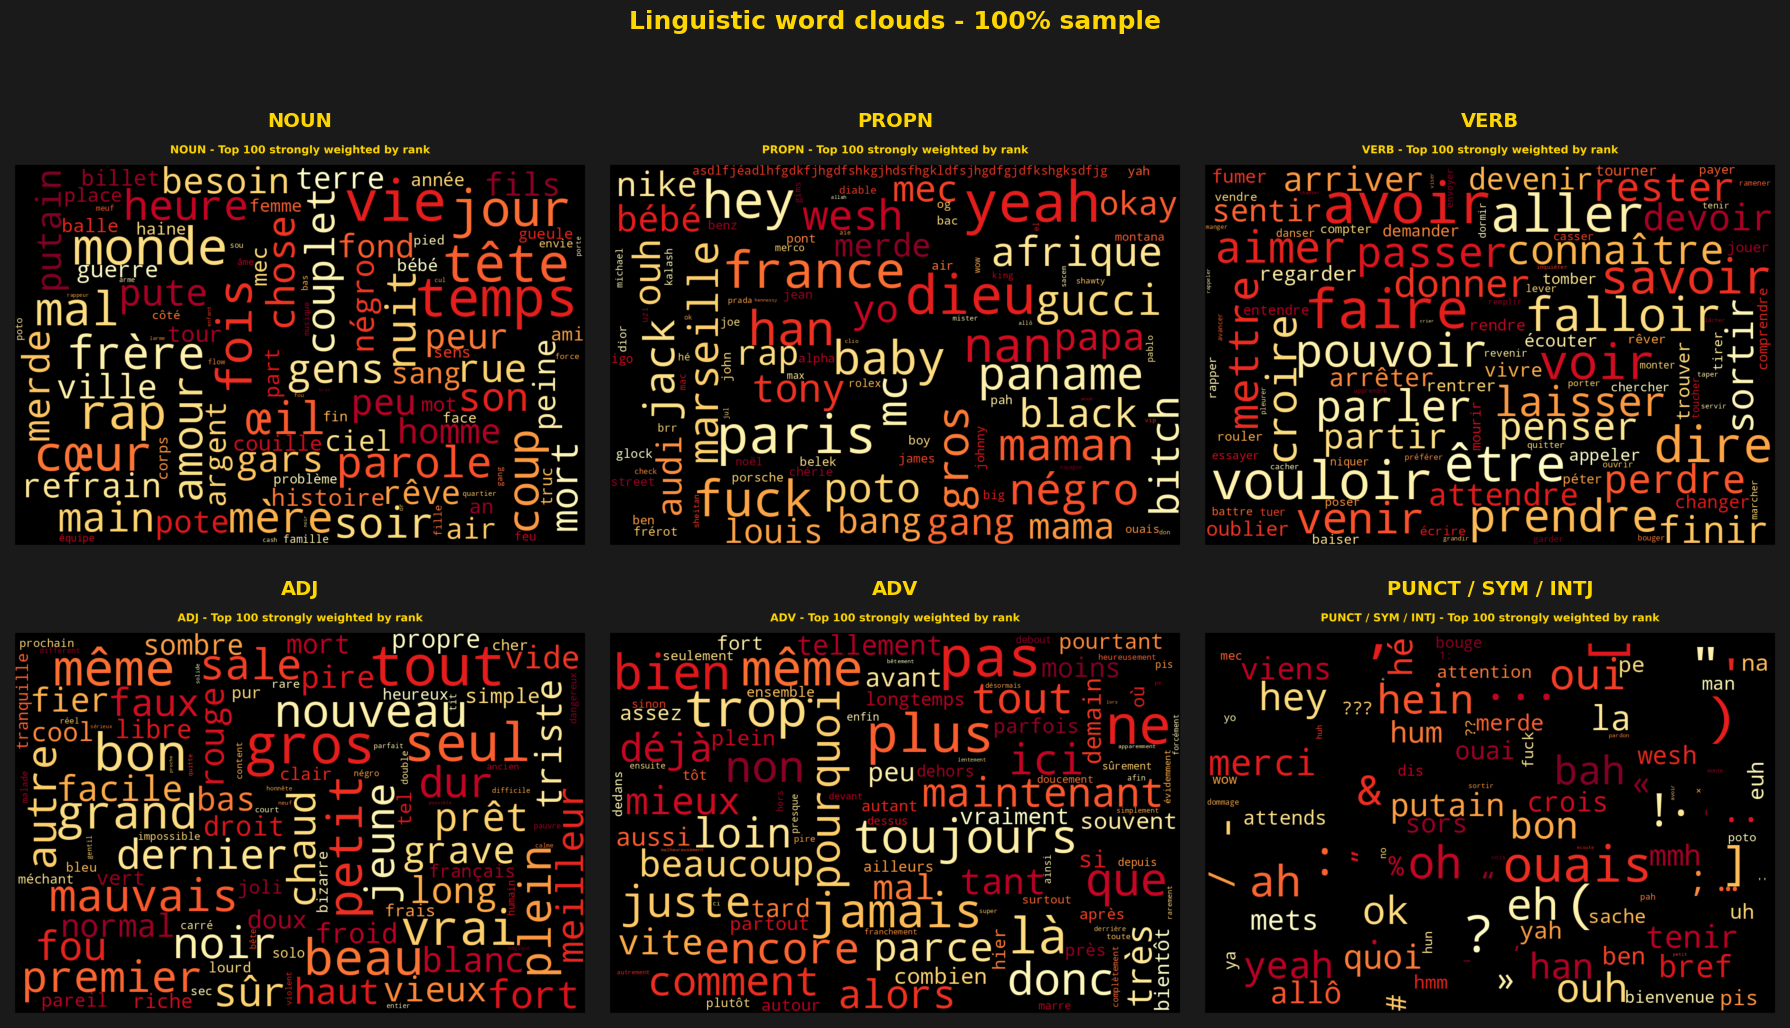

In [38]:
# Reload and display the six saved linguistic word clouds.
final_wordcloud_categories = ['NOUN', 'PROPN', 'VERB', 'ADJ', 'ADV', 'EXPRESSIVE']
final_category_titles = {
    'NOUN': 'NOUN',
    'PROPN': 'PROPN',
    'VERB': 'VERB',
    'ADJ': 'ADJ',
    'ADV': 'ADV',
    'EXPRESSIVE': 'PUNCT / SYM / INTJ',
}
final_category_slugs = {
    'NOUN': 'noun',
    'PROPN': 'propn',
    'VERB': 'verb',
    'ADJ': 'adj',
    'ADV': 'adv',
    'EXPRESSIVE': 'expressive',
}
figure, axes = plt.subplots(
    2,
    3,
    figsize=(18, 11),
    facecolor=HIP_HOP_PALETTE['dark_gray'],
)

for axis, category in zip(axes.flat, final_wordcloud_categories):
    image_path = images_dir / (
        f"02_wordcloud_rank_{final_category_slugs[category]}_{sample_label}.png"
    )
    if not image_path.exists():
        raise FileNotFoundError(
            f'Missing word cloud for {category}; run section 7 first.'
        )
    axis.imshow(plt.imread(image_path))
    axis.set_title(
        final_category_titles[category],
        fontsize=14,
        fontweight='bold',
        color=HIP_HOP_PALETTE['gold'],
        pad=10,
    )
    axis.axis('off')

figure.suptitle(
    f'Linguistic word clouds - {sample_fraction:.0%} sample',
    fontsize=18,
    fontweight='bold',
    color=HIP_HOP_PALETTE['gold'],
)
figure.tight_layout(rect=(0, 0, 1, 0.96))
plt.show()